In [ ]:
!pip -q install xgboost joblib

import os
import json
import warnings
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    classification_report,
    confusion_matrix,
    accuracy_score
)
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge
from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor,
    HistGradientBoostingRegressor
)
from sklearn.base import clone
from sklearn.inspection import permutation_importance

import joblib

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

OUTPUT_DIR = Path("/content/cardamom_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Setup completed.")

Setup completed.


In [ ]:
from google.colab import files

uploaded = files.upload()

MARKET_CSV = "/content/cardamom_raw_market_dataset.csv"
SCENARIO_CSV = "/content/cardamom_raw_profit_input_scenarios.csv"

market_raw = pd.read_csv(MARKET_CSV)
scenario_raw = pd.read_csv(SCENARIO_CSV)

print("Market dataset shape:", market_raw.shape)
print("Profit scenario dataset shape:", scenario_raw.shape)

print("\nMarket columns:")
print(market_raw.columns.tolist())

print("\nScenario columns:")
print(scenario_raw.columns.tolist())

Saving cardamom_raw_market_dataset.csv to cardamom_raw_market_dataset.csv
Saving cardamom_raw_profit_input_scenarios.csv to cardamom_raw_profit_input_scenarios.csv
Market dataset shape: (10416, 31)
Profit scenario dataset shape: (20832, 23)

Market columns:
['date', 'year', 'month', 'week_of_year', 'quarter', 'season', 'region', 'production_zone', 'altitude_m', 'grade', 'grade_description', 'dried_price_lkr_per_kg', 'fresh_price_lkr_per_kg_est', 'usd_lkr_rate_est', 'diesel_price_lkr_litre_est', 'kerosene_price_lkr_litre_est', 'labour_cost_lkr_day_est', 'electricity_price_lkr_kwh_est', 'rainfall_mm_est', 'temperature_c_est', 'humidity_pct_est', 'production_supply_index_est', 'global_export_demand_index_est', 'fuel_drying_cost_lkr_per_dried_kg_est', 'labour_drying_cost_lkr_per_dried_kg_est', 'electricity_drying_cost_lkr_per_dried_kg_est', 'barn_rental_lkr_per_dried_kg_est', 'packaging_transport_lkr_per_dried_kg_est', 'total_drying_cost_lkr_per_dried_kg_est', 'fresh_to_dried_conversion_ra

In [ ]:
def clean_column_names(df):
    df = df.copy()
    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
        .str.replace(" ", "_", regex=False)
        .str.replace("-", "_", regex=False)
    )
    return df


def parse_date(df, date_col="date"):
    df = df.copy()
    df[date_col] = pd.to_datetime(df[date_col], errors="coerce")

    if df[date_col].isna().sum() > 0:
        raise ValueError("Some date values could not be parsed.")

    return df


def infer_season(month):
    if month in [9, 10, 11, 12, 1]:
        return "main_harvest"
    elif month in [2, 8]:
        return "shoulder"
    else:
        return "off_season"


def add_time_columns(df):
    df = df.copy()

    df["year"] = df["date"].dt.year
    df["month"] = df["date"].dt.month
    df["quarter"] = df["date"].dt.quarter
    df["week_of_year"] = df["date"].dt.isocalendar().week.astype(int)

    if "season" not in df.columns:
        df["season"] = df["month"].apply(infer_season)

    return df


def convert_possible_numeric_columns(df, skip_cols):
    df = df.copy()
    skip_cols = set(skip_cols)

    for col in df.columns:
        if col in skip_cols:
            continue

        if df[col].dtype == "object":
            converted = pd.to_numeric(df[col], errors="coerce")

            original_not_null = df[col].notna().sum()
            converted_not_null = converted.notna().sum()

            if original_not_null > 0 and converted_not_null / original_not_null > 0.80:
                df[col] = converted

    return df


market = clean_column_names(market_raw)
scenario = clean_column_names(scenario_raw)

market = parse_date(market)
scenario = parse_date(scenario)

market = add_time_columns(market)
scenario = add_time_columns(scenario)

market = convert_possible_numeric_columns(
    market,
    skip_cols=[
        "date",
        "region",
        "production_zone",
        "grade",
        "grade_description",
        "season",
        "data_source_class"
    ]
)

scenario = convert_possible_numeric_columns(
    scenario,
    skip_cols=[
        "scenario_id",
        "date",
        "season",
        "region",
        "grade",
        "dryer_access_profile"
    ]
)

required_market_cols = [
    "date",
    "region",
    "grade",
    "dried_price_lkr_per_kg"
]

required_scenario_cols = [
    "date",
    "region",
    "grade",
    "harvest_fresh_kg",
    "fresh_to_dried_conversion_ratio_est",
    "current_fresh_price_lkr_per_kg",
    "current_dried_price_lkr_per_kg",
    "drying_cost_total_lkr",
    "storage_weeks",
    "storage_cost_total_lkr",
    "quality_loss_pct_est"
]

missing_market = [c for c in required_market_cols if c not in market.columns]
missing_scenario = [c for c in required_scenario_cols if c not in scenario.columns]

if missing_market:
    raise ValueError(f"Market dataset missing columns: {missing_market}")

if missing_scenario:
    raise ValueError(f"Scenario dataset missing columns: {missing_scenario}")

market = market.sort_values(["region", "grade", "date"]).reset_index(drop=True)
scenario = scenario.sort_values(["region", "grade", "date"]).reset_index(drop=True)

print("Cleaned market shape:", market.shape)
print("Cleaned scenario shape:", scenario.shape)

display(market.head())
display(scenario.head())

Cleaned market shape: (10416, 31)
Cleaned scenario shape: (20832, 25)


,date,year,month,week_of_year,quarter,season,region,production_zone,altitude_m,grade,...,production_supply_index_est,global_export_demand_index_est,fuel_drying_cost_lkr_per_dried_kg_est,labour_drying_cost_lkr_per_dried_kg_est,electricity_drying_cost_lkr_per_dried_kg_est,barn_rental_lkr_per_dried_kg_est,packaging_transport_lkr_per_dried_kg_est,total_drying_cost_lkr_per_dried_kg_est,fresh_to_dried_conversion_ratio_est,data_source_class
0,2018-01-01,2018,1,1,1,main_harvest,Badulla,Uva highland,750,LB,...,120.28,87.49,85.23,43.08,29.90,69.52,109.52,337.25,4.12,source_calibrated_synthetic
1,2018-01-08,2018,1,2,1,main_harvest,Badulla,Uva highland,750,LB,...,113.97,88.41,101.28,66.73,44.74,63.93,76.66,353.34,4.08,source_calibrated_synthetic
2,2018-01-15,2018,1,3,1,main_harvest,Badulla,Uva highland,750,LB,...,115.00,93.64,81.26,62.20,34.60,76.62,111.61,366.29,3.97,source_calibrated_synthetic
3,2018-01-22,2018,1,4,1,main_harvest,Badulla,Uva highland,750,LB,...,121.28,87.28,114.37,57.84,53.90,54.04,138.38,418.53,4.10,source_calibrated_synthetic
4,2018-01-29,2018,1,5,1,main_harvest,Badulla,Uva highland,750,LB,...,113.64,89.58,141.21,49.54,53.18,111.83,131.93,487.69,4.53,source_calibrated_synthetic


,scenario_id,date,year,month,season,region,grade,dryer_access_profile,harvest_fresh_kg,moisture_pct_est,...,storage_cost_total_lkr,quality_loss_pct_est,usd_lkr_rate_est,diesel_price_lkr_litre_est,kerosene_price_lkr_litre_est,labour_cost_lkr_day_est,production_supply_index_est,global_export_demand_index_est,quarter,week_of_year
0,SCN-000031,2018-01-01,2018,1,main_harvest,Badulla,LB,average_shared_dryer,359.0,77.6,...,5396.69,1.517692,163.25,123.59,72.43,941.32,120.28,87.49,1,1
1,SCN-000032,2018-01-01,2018,1,main_harvest,Badulla,LB,average_shared_dryer,79.4,67.3,...,1586.42,2.554381,163.25,123.59,72.43,941.32,120.28,87.49,1,1
2,SCN-000079,2018-01-08,2018,1,main_harvest,Badulla,LB,high_cost_rented_dryer,288.9,63.4,...,4600.98,4.221494,162.59,120.81,73.25,989.88,113.97,88.41,1,2
3,SCN-000080,2018-01-08,2018,1,main_harvest,Badulla,LB,low_cost_owned_dryer,130.6,61.5,...,4133.89,2.240010,162.59,120.81,73.25,989.88,113.97,88.41,1,2
4,SCN-000127,2018-01-15,2018,1,main_harvest,Badulla,LB,low_cost_owned_dryer,564.4,65.6,...,27999.88,4.241226,163.95,121.54,71.37,974.72,115.00,93.64,1,3


In [ ]:
HORIZON_WEEKS = 4
TARGET_COL = f"target_dried_price_next_{HORIZON_WEEKS}w_lkr_per_kg"


def create_market_features(df, horizon_weeks=4):
    df = df.copy()
    df = df.sort_values(["region", "grade", "date"]).reset_index(drop=True)

    group_keys = ["region", "grade"]
    price_col = "dried_price_lkr_per_kg"

    # Target: dried price after next 4 weeks
    df[TARGET_COL] = df.groupby(group_keys)[price_col].shift(-horizon_weeks)
    df["target_available"] = df[TARGET_COL].notna()

    # Cyclic time features
    df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)
    df["week_sin"] = np.sin(2 * np.pi * df["week_of_year"] / 52)
    df["week_cos"] = np.cos(2 * np.pi * df["week_of_year"] / 52)

    # Lag price features
    for lag in [1, 2, 4, 8, 12, 26, 52]:
        df[f"dried_price_lag_{lag}w"] = df.groupby(group_keys)[price_col].shift(lag)

    # Rolling price features
    for window in [4, 8, 12, 26, 52]:
        df[f"dried_rollmean_{window}w"] = df.groupby(group_keys)[price_col].transform(
            lambda s: s.shift(1).rolling(window, min_periods=2).mean()
        )

        df[f"dried_rollstd_{window}w"] = df.groupby(group_keys)[price_col].transform(
            lambda s: s.shift(1).rolling(window, min_periods=2).std()
        )

        df[f"dried_rollmin_{window}w"] = df.groupby(group_keys)[price_col].transform(
            lambda s: s.shift(1).rolling(window, min_periods=2).min()
        )

        df[f"dried_rollmax_{window}w"] = df.groupby(group_keys)[price_col].transform(
            lambda s: s.shift(1).rolling(window, min_periods=2).max()
        )

    # Momentum features
    for period in [1, 4, 12, 26]:
        df[f"dried_pct_change_{period}w"] = (
            df.groupby(group_keys)[price_col].pct_change(periods=period) * 100
        )

    # Price ratio feature
    if "fresh_price_lkr_per_kg_est" in df.columns:
        df["dried_to_fresh_price_ratio"] = (
            df["dried_price_lkr_per_kg"] /
            df["fresh_price_lkr_per_kg_est"].replace(0, np.nan)
        )

    # Drying cost ratio feature
    if "total_drying_cost_lkr_per_dried_kg_est" in df.columns:
        df["drying_cost_share_of_price_pct"] = (
            df["total_drying_cost_lkr_per_dried_kg_est"] /
            df["dried_price_lkr_per_kg"].replace(0, np.nan)
        ) * 100

    # Macro lag orchange features, only if columns exist
    macro_cols = [
        "usd_lkr_rate_est",
        "diesel_price_lkr_litre_est",
        "kerosene_price_lkr_litre_est",
        "labour_cost_lkr_day_est",
        "production_supply_index_est",
        "global_export_demand_index_est"
    ]

    for col in macro_cols:
        if col in df.columns:
            df[f"{col}_lag_4w"] = df.groupby(group_keys)[col].shift(4)
            df[f"{col}_change_4w"] = df[col] - df[f"{col}_lag_4w"]

    return df


market_fe = create_market_features(market, horizon_weeks=HORIZON_WEEKS)

print("Feature-engineered market shape:", market_fe.shape)
print("Rows with target available:", market_fe["target_available"].sum())

display(market_fe.head())

market_fe.to_csv(OUTPUT_DIR / "processed_market_features_with_targets.csv", index=False)

Feature-engineered market shape: (10416, 82)
Rows with target available: 10320


,date,year,month,week_of_year,quarter,season,region,production_zone,altitude_m,grade,...,diesel_price_lkr_litre_est_lag_4w,diesel_price_lkr_litre_est_change_4w,kerosene_price_lkr_litre_est_lag_4w,kerosene_price_lkr_litre_est_change_4w,labour_cost_lkr_day_est_lag_4w,labour_cost_lkr_day_est_change_4w,production_supply_index_est_lag_4w,production_supply_index_est_change_4w,global_export_demand_index_est_lag_4w,global_export_demand_index_est_change_4w
0,2018-01-01,2018,1,1,1,main_harvest,Badulla,Uva highland,750,LB,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2018-01-08,2018,1,2,1,main_harvest,Badulla,Uva highland,750,LB,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2018-01-15,2018,1,3,1,main_harvest,Badulla,Uva highland,750,LB,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2018-01-22,2018,1,4,1,main_harvest,Badulla,Uva highland,750,LB,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2018-01-29,2018,1,5,1,main_harvest,Badulla,Uva highland,750,LB,...,123.59,5.04,72.43,1.43,941.32,29.4,120.28,-6.64,87.49,2.09


In [ ]:
model_df = market_fe[market_fe["target_available"] == True].copy()
model_df = model_df.sort_values("date").reset_index(drop=True)

exclude_cols = {
    "date",
    "grade_description",
    "data_source_class",
    TARGET_COL,
    "target_available"
}

feature_cols = [c for c in model_df.columns if c not in exclude_cols]

X_all = model_df[feature_cols].copy()
y_all = model_df[TARGET_COL].copy()

unique_dates = np.array(sorted(model_df["date"].unique()))

train_end_date = unique_dates[int(len(unique_dates) * 0.70)]
valid_end_date = unique_dates[int(len(unique_dates) * 0.85)]

train_mask = model_df["date"] <= train_end_date
valid_mask = (model_df["date"] > train_end_date) & (model_df["date"] <= valid_end_date)
test_mask = model_df["date"] > valid_end_date

X_train = X_all.loc[train_mask]
y_train = y_all.loc[train_mask]

X_valid = X_all.loc[valid_mask]
y_valid = y_all.loc[valid_mask]

X_test = X_all.loc[test_mask]
y_test = y_all.loc[test_mask]

print("Train:", X_train.shape, model_df.loc[train_mask, "date"].min(), "to", model_df.loc[train_mask, "date"].max())
print("Valid:", X_valid.shape, model_df.loc[valid_mask, "date"].min(), "to", model_df.loc[valid_mask, "date"].max())
print("Test :", X_test.shape, model_df.loc[test_mask, "date"].min(), "to", model_df.loc[test_mask, "date"].max())

numeric_features = X_train.select_dtypes(include=[np.number, "bool"]).columns.tolist()
categorical_features = [c for c in X_train.columns if c not in numeric_features]

print("Numeric features:", len(numeric_features))
print("Categorical features:", categorical_features)

Train: (7248, 77) 2018-01-01 00:00:00 to 2023-10-09 00:00:00
Valid: (1536, 77) 2023-10-16 00:00:00 to 2024-12-30 00:00:00
Test : (1536, 77) 2025-01-06 00:00:00 to 2026-03-23 00:00:00
Numeric features: 73
Categorical features: ['season', 'region', 'production_zone', 'grade']


In [ ]:
try:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse=False)

numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", onehot)
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features)
    ],
    remainder="drop"
)

In [ ]:
def regression_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    y_true_safe = np.where(np.array(y_true) == 0, np.nan, np.array(y_true))
    mape = np.nanmean(np.abs((np.array(y_true) - np.array(y_pred)) / y_true_safe)) * 100

    return {
        "MAE": float(mae),
        "RMSE": float(rmse),
        "R2": float(r2),
        "MAPE_%": float(mape)
    }


models = {
    "dummy_mean_baseline": DummyRegressor(strategy="mean"),

    "ridge_regression": Ridge(alpha=1.0),

    "random_forest": RandomForestRegressor(
        n_estimators=450,
        max_depth=None,
        min_samples_leaf=2,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "extra_trees": ExtraTreesRegressor(
        n_estimators=500,
        max_depth=None,
        min_samples_leaf=2,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "gradient_boosting": GradientBoostingRegressor(
        n_estimators=450,
        learning_rate=0.03,
        max_depth=4,
        random_state=RANDOM_STATE
    ),

    "hist_gradient_boosting": HistGradientBoostingRegressor(
        max_iter=700,
        learning_rate=0.03,
        max_leaf_nodes=31,
        l2_regularization=0.05,
        random_state=RANDOM_STATE
    )
}

try:
    from xgboost import XGBRegressor

    models["xgboost"] = XGBRegressor(
        n_estimators=800,
        learning_rate=0.03,
        max_depth=5,
        subsample=0.9,
        colsample_bytree=0.9,
        objective="reg:squarederror",
        random_state=RANDOM_STATE,
        tree_method="hist",
        n_jobs=-1
    )

    print("XGBoost added.")

except Exception as e:
    print("XGBoost not available:", e)


results = []
trained_pipelines = {}

for name, model in models.items():
    print("\nTraining:", name)

    pipe = Pipeline(steps=[
        ("preprocess", clone(preprocess)),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)

    trained_pipelines[name] = pipe

    train_pred = pipe.predict(X_train)
    valid_pred = pipe.predict(X_valid)

    train_metrics = regression_metrics(y_train, train_pred)
    valid_metrics = regression_metrics(y_valid, valid_pred)

    print("Train:", train_metrics)
    print("Valid:", valid_metrics)

    results.append({
        "model": name,
        **{f"train_{k}": v for k, v in train_metrics.items()},
        **{f"valid_{k}": v for k, v in valid_metrics.items()}
    })


results_df = pd.DataFrame(results).sort_values("valid_MAE")
display(results_df)

results_df.to_csv(OUTPUT_DIR / "model_validation_comparison.csv", index=False)

best_model_name = results_df.iloc[0]["model"]
print("Best model:", best_model_name)

XGBoost added.

Training: dummy_mean_baseline
Train: {'MAE': 1068.723861435171, 'RMSE': 1345.8664924920804, 'R2': 0.0, 'MAPE_%': 28.600368997775327}
Valid: {'MAE': 6028.672864109064, 'RMSE': 6584.310074707501, 'R2': -5.186021414913564, 'MAPE_%': 55.29689705184916}

Training: ridge_regression
Train: {'MAE': 161.57856539622918, 'RMSE': 209.30721875878632, 'R2': 0.975813977519985, 'MAPE_%': 3.93175958983863}
Valid: {'MAE': 952.5598712320885, 'RMSE': 1139.1729412744314, 'R2': 0.8148301858879877, 'MAPE_%': 8.900500493343875}

Training: random_forest
Train: {'MAE': 61.03576924772403, 'RMSE': 81.3578254771327, 'R2': 0.9963457798926426, 'MAPE_%': 1.4423437099756231}
Valid: {'MAE': 2419.3688708939103, 'RMSE': 3108.3590064792393, 'R2': -0.37864742780989014, 'MAPE_%': 20.434888487105603}

Training: extra_trees
Train: {'MAE': 15.321671025570243, 'RMSE': 24.46523973092495, 'R2': 0.9996695581919471, 'MAPE_%': 0.36464900118463334}
Valid: {'MAE': 2477.454039993491, 'RMSE': 3184.6827562642625, 'R2': -0

,model,train_MAE,train_RMSE,train_R2,train_MAPE_%,valid_MAE,valid_RMSE,valid_R2,valid_MAPE_%
1,ridge_regression,161.578565,209.307219,0.975814,3.931760,952.559871,1139.172941,0.814830,8.900500
2,random_forest,61.035769,81.357825,0.996346,1.442344,2419.368871,3108.359006,-0.378647,20.434888
5,hist_gradient_boosting,74.594921,94.643910,0.995055,1.854624,2437.418636,3135.999166,-0.403275,20.546508
4,gradient_boosting,119.971059,152.587620,0.987146,2.878267,2446.859781,3139.256262,-0.406191,20.686863
3,extra_trees,15.321671,24.465240,0.999670,0.364649,2477.454040,3184.682756,-0.447182,20.877327
6,xgboost,81.044414,102.600800,0.994188,2.003601,2506.505079,3198.645154,-0.459900,21.222607
0,dummy_mean_baseline,1068.723861,1345.866492,0.000000,28.600369,6028.672864,6584.310075,-5.186021,55.296897


Best model: ridge_regression


In [ ]:
X_trainval = pd.concat([X_train, X_valid], axis=0)
y_trainval = pd.concat([y_train, y_valid], axis=0)

final_price_model = Pipeline(steps=[
    ("preprocess", clone(preprocess)),
    ("model", clone(models[best_model_name]))
])

final_price_model.fit(X_trainval, y_trainval)

test_pred = final_price_model.predict(X_test)

test_metrics = regression_metrics(y_test, test_pred)

print("Final test metrics:")
print(test_metrics)

joblib.dump(final_price_model, OUTPUT_DIR / "cardamom_dried_price_prediction_model.joblib")

metadata = {
    "created_at": datetime.utcnow().isoformat() + "Z",
    "horizon_weeks": HORIZON_WEEKS,
    "target_col": TARGET_COL,
    "best_model_name": best_model_name,
    "feature_cols": feature_cols,
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "test_metrics": test_metrics
}

with open(OUTPUT_DIR / "training_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

test_predictions_df = model_df.loc[test_mask, ["date", "region", "grade", "dried_price_lkr_per_kg", TARGET_COL]].copy()
test_predictions_df["predicted_dried_price_next_4w_lkr_per_kg"] = test_pred
test_predictions_df["absolute_error"] = abs(
    test_predictions_df[TARGET_COL] -
    test_predictions_df["predicted_dried_price_next_4w_lkr_per_kg"]
)

display(test_predictions_df.head())

test_predictions_df.to_csv(OUTPUT_DIR / "test_price_predictions.csv", index=False)

Final test metrics:
{'MAE': 684.8705057315912, 'RMSE': 853.1685934061281, 'R2': 0.9028216662532104, 'MAPE_%': 5.148039299576496}


,date,region,grade,dried_price_lkr_per_kg,target_dried_price_next_4w_lkr_per_kg,predicted_dried_price_next_4w_lkr_per_kg,absolute_error
8784,2025-01-06,Ratnapura,LLG1,12063.24,13050.34,13060.165240,9.825240
8785,2025-01-06,Badulla,LG,15164.51,15705.62,15865.105066,159.485066
8786,2025-01-06,Badulla,LLG1,13519.53,14573.97,14226.152127,347.817873
8787,2025-01-06,Matale,LLG1,13967.71,15176.52,14921.917053,254.602947
8788,2025-01-06,Kandy,LLG2,12422.95,12796.04,13042.025983,245.985983


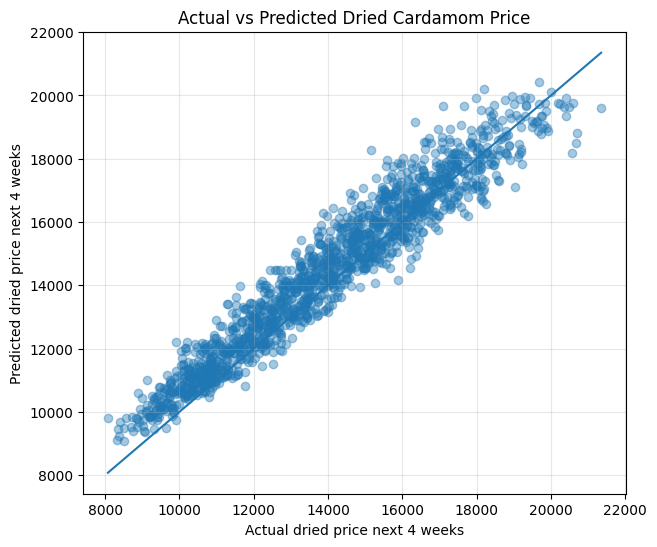

In [ ]:
plt.figure(figsize=(7, 6))
plt.scatter(y_test, test_pred, alpha=0.4)

min_value = min(y_test.min(), test_pred.min())
max_value = max(y_test.max(), test_pred.max())

plt.plot([min_value, max_value], [min_value, max_value])
plt.xlabel("Actual dried price next 4 weeks")
plt.ylabel("Predicted dried price next 4 weeks")
plt.title("Actual vs Predicted Dried Cardamom Price")
plt.grid(True, alpha=0.3)
plt.savefig(OUTPUT_DIR / "actual_vs_predicted_price.png", dpi=160, bbox_inches="tight")
plt.show()

,feature,importance_mae_reduction,importance_std
9,dried_price_lkr_per_kg,1060.190246,17.199733
47,dried_rollmean_12w,551.016181,10.122803
32,dried_price_lag_1w,362.732991,10.474867
55,dried_rollmean_52w,302.254409,11.579430
53,dried_rollmin_26w,280.789688,12.913067
57,dried_rollmin_52w,229.909867,8.130958
43,dried_rollmean_8w,183.694167,6.615007
33,dried_price_lag_2w,177.997659,7.104803
34,dried_price_lag_4w,143.917002,6.179993
46,dried_rollmax_8w,128.508517,9.127379


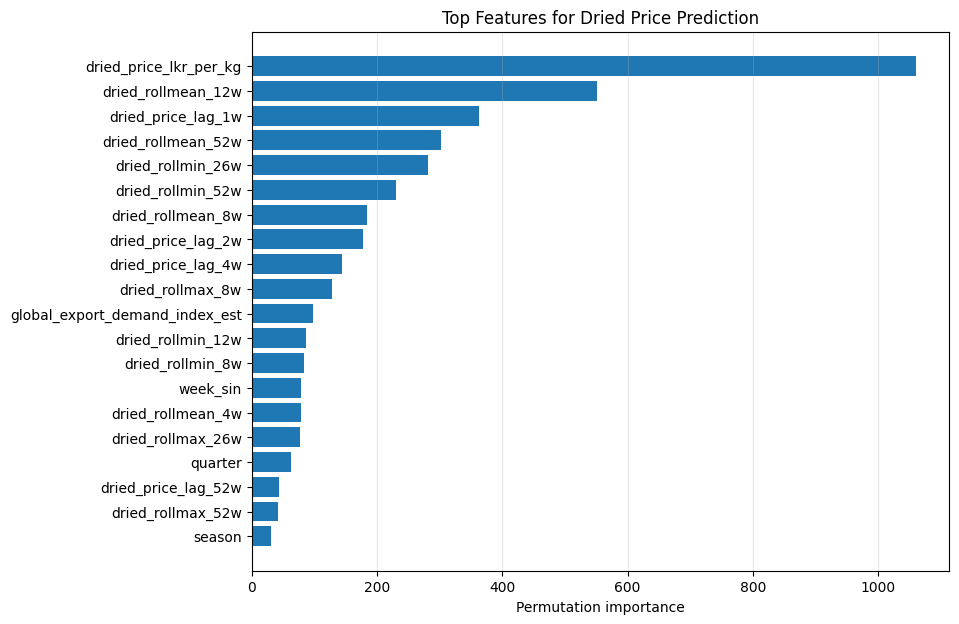

In [ ]:
perm = permutation_importance(
    final_price_model,
    X_test,
    y_test,
    n_repeats=5,
    random_state=RANDOM_STATE,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

importance_df = pd.DataFrame({
    "feature": feature_cols,
    "importance_mae_reduction": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mae_reduction", ascending=False)

display(importance_df.head(25))

importance_df.to_csv(OUTPUT_DIR / "feature_importance.csv", index=False)

top_features = importance_df.head(20).sort_values("importance_mae_reduction")

plt.figure(figsize=(9, 7))
plt.barh(top_features["feature"], top_features["importance_mae_reduction"])
plt.xlabel("Permutation importance")
plt.title("Top Features for Dried Price Prediction")
plt.grid(True, axis="x", alpha=0.3)
plt.savefig(OUTPUT_DIR / "feature_importance.png", dpi=160, bbox_inches="tight")
plt.show()

In [ ]:
market_predictions = market_fe.copy()

market_predictions["predicted_dried_price_next_4w_lkr_per_kg"] = final_price_model.predict(
    market_predictions[feature_cols]
)

market_predictions.to_csv(
    OUTPUT_DIR / "market_with_predicted_future_prices.csv",
    index=False
)

display(
    market_predictions[
        [
            "date",
            "region",
            "grade",
            "dried_price_lkr_per_kg",
            "predicted_dried_price_next_4w_lkr_per_kg",
            TARGET_COL,
            "target_available"
        ]
    ].head()
)

,date,region,grade,dried_price_lkr_per_kg,predicted_dried_price_next_4w_lkr_per_kg,target_dried_price_next_4w_lkr_per_kg,target_available
0,2018-01-01,Badulla,LB,1910.75,2598.917289,1768.20,True
1,2018-01-08,Badulla,LB,1997.24,2123.063979,1952.08,True
2,2018-01-15,Badulla,LB,1776.90,1871.221981,1936.08,True
3,2018-01-22,Badulla,LB,1827.69,1555.330120,1847.85,True
4,2018-01-29,Badulla,LB,1768.20,1873.222162,1820.28,True


In [ ]:
def make_recommendation(diff_lkr, fresh_revenue_lkr, hold_pct=0.08, min_hold_lkr=3000):
    """
    diff_lkr = predicted dried net profit - fresh revenue

    DRY_AND_STORE = drying is clearly better
    SELL_FRESH = fresh sale is clearly better
    HOLD_MONITOR = difference is small/uncertain
    """

    if pd.isna(diff_lkr):
        return "UNKNOWN"

    threshold = max(abs(fresh_revenue_lkr) * hold_pct, min_hold_lkr)

    if diff_lkr > threshold:
        return "DRY_AND_STORE"
    elif diff_lkr < -threshold:
        return "SELL_FRESH"
    else:
        return "HOLD_MONITOR"


def build_profit_recommendations(scenario_df, market_pred_df):
    sc = scenario_df.copy()
    sc["date"] = pd.to_datetime(sc["date"])

    lookup_cols = [
        "date",
        "region",
        "grade",
        TARGET_COL,
        "target_available",
        "predicted_dried_price_next_4w_lkr_per_kg"
    ]

    lookup = market_pred_df[lookup_cols].drop_duplicates(["date", "region", "grade"])

    out = sc.merge(
        lookup,
        on=["date", "region", "grade"],
        how="left"
    )

    # Fresh revenue
    out["fresh_revenue_lkr"] = (
        out["harvest_fresh_kg"] *
        out["current_fresh_price_lkr_per_kg"]
    )

    # Dried quantity after conversion ratio
    out["expected_dried_quantity_kg"] = (
        out["harvest_fresh_kg"] /
        out["fresh_to_dried_conversion_ratio_est"].replace(0, np.nan)
    )

    # Predicted dried revenue
    out["predicted_dried_gross_revenue_lkr"] = (
        out["expected_dried_quantity_kg"] *
        out["predicted_dried_price_next_4w_lkr_per_kg"]
    )

    # Predicted quality loss
    out["predicted_quality_loss_cost_lkr"] = (
        out["predicted_dried_gross_revenue_lkr"] *
        out["quality_loss_pct_est"].fillna(0) / 100
    )

    # Predicted dried net profit
    out["predicted_dried_net_profit_lkr"] = (
        out["predicted_dried_gross_revenue_lkr"]
        - out["drying_cost_total_lkr"].fillna(0)
        - out["storage_cost_total_lkr"].fillna(0)
        - out["predicted_quality_loss_cost_lkr"].fillna(0)
    )

    out["predicted_profit_difference_lkr"] = (
        out["predicted_dried_net_profit_lkr"] -
        out["fresh_revenue_lkr"]
    )

    out["recommendation_label"] = out.apply(
        lambda r: make_recommendation(
            r["predicted_profit_difference_lkr"],
            r["fresh_revenue_lkr"]
        ),
        axis=1
    )

    # Actual historical backtesting values
    out["actual_dried_gross_revenue_lkr"] = (
        out["expected_dried_quantity_kg"] *
        out[TARGET_COL]
    )

    out["actual_quality_loss_cost_lkr"] = (
        out["actual_dried_gross_revenue_lkr"] *
        out["quality_loss_pct_est"].fillna(0) / 100
    )

    out["actual_dried_net_profit_lkr"] = (
        out["actual_dried_gross_revenue_lkr"]
        - out["drying_cost_total_lkr"].fillna(0)
        - out["storage_cost_total_lkr"].fillna(0)
        - out["actual_quality_loss_cost_lkr"].fillna(0)
    )

    out["actual_profit_difference_lkr"] = (
        out["actual_dried_net_profit_lkr"] -
        out["fresh_revenue_lkr"]
    )

    out["actual_dry_profitable"] = out["actual_profit_difference_lkr"] > 0

    out["actual_recommendation_label"] = out.apply(
        lambda r: make_recommendation(
            r["actual_profit_difference_lkr"],
            r["fresh_revenue_lkr"]
        ),
        axis=1
    )

    return out


scenario_results = build_profit_recommendations(scenario, market_predictions)

scenario_results.to_csv(
    OUTPUT_DIR / "profit_recommendation_results.csv",
    index=False
)

display(scenario_results.head())

print("Recommendation distribution:")
print(scenario_results["recommendation_label"].value_counts())

,scenario_id,date,year,month,season,region,grade,dryer_access_profile,harvest_fresh_kg,moisture_pct_est,...,predicted_quality_loss_cost_lkr,predicted_dried_net_profit_lkr,predicted_profit_difference_lkr,recommendation_label,actual_dried_gross_revenue_lkr,actual_quality_loss_cost_lkr,actual_dried_net_profit_lkr,actual_profit_difference_lkr,actual_dry_profitable,actual_recommendation_label
0,SCN-000031,2018-01-01,2018,1,main_harvest,Badulla,LB,average_shared_dryer,359.0,77.6,...,3174.942069,164373.398187,87472.008187,DRY_AND_STORE,142328.206278,2160.104360,98521.081918,21619.691918,True,DRY_AND_STORE
1,SCN-000032,2018-01-01,2018,1,main_harvest,Badulla,LB,average_shared_dryer,79.4,67.3,...,1246.115605,33734.543672,17325.739672,DRY_AND_STORE,33190.326241,847.807517,18539.718724,2130.914724,True,HOLD_MONITOR
2,SCN-000079,2018-01-08,2018,1,main_harvest,Badulla,LB,high_cost_rented_dryer,288.9,63.4,...,6760.486936,83237.797438,-2085.928562,HOLD_MONITOR,147246.974413,6216.021498,70884.802915,-14438.923085,False,SELL_FRESH
3,SCN-000080,2018-01-08,2018,1,main_harvest,Badulla,LB,low_cost_owned_dryer,130.6,61.5,...,1613.227181,52498.824562,23371.106562,DRY_AND_STORE,66218.609870,1483.303634,46828.616236,17700.898236,True,DRY_AND_STORE
4,SCN-000127,2018-01-15,2018,1,main_harvest,Badulla,LB,low_cost_owned_dryer,564.4,65.6,...,11397.541972,186738.073733,20906.065733,DRY_AND_STORE,278046.705344,11792.589699,195657.495645,29825.487645,True,DRY_AND_STORE


Recommendation distribution:
recommendation_label
DRY_AND_STORE    15934
HOLD_MONITOR      3047
SELL_FRESH        1851
Name: count, dtype: int64


In [ ]:
eval_scen = scenario_results[scenario_results["target_available"] == True].copy()

eval_scen = eval_scen.dropna(
    subset=[
        "actual_recommendation_label",
        "recommendation_label"
    ]
)

print("Backtesting rows:", eval_scen.shape)

print("\nClassification report:")
print(
    classification_report(
        eval_scen["actual_recommendation_label"],
        eval_scen["recommendation_label"]
    )
)

labels = ["DRY_AND_STORE", "HOLD_MONITOR", "SELL_FRESH"]

cm = confusion_matrix(
    eval_scen["actual_recommendation_label"],
    eval_scen["recommendation_label"],
    labels=labels
)

cm_df = pd.DataFrame(
    cm,
    index=[f"Actual_{x}" for x in labels],
    columns=[f"Predicted_{x}" for x in labels]
)

display(cm_df)

cm_df.to_csv(OUTPUT_DIR / "recommendation_confusion_matrix.csv")

accuracy = accuracy_score(
    eval_scen["actual_recommendation_label"],
    eval_scen["recommendation_label"]
)

print("Recommendation accuracy:", accuracy)

Backtesting rows: (20640, 41)

Classification report:
               precision    recall  f1-score   support

DRY_AND_STORE       0.95      0.96      0.95     15589
 HOLD_MONITOR       0.65      0.64      0.65      3080
   SELL_FRESH       0.83      0.78      0.80      1971

     accuracy                           0.89     20640
    macro avg       0.81      0.79      0.80     20640
 weighted avg       0.89      0.89      0.89     20640



,Predicted_DRY_AND_STORE,Predicted_HOLD_MONITOR,Predicted_SELL_FRESH
Actual_DRY_AND_STORE,14946,624,19
Actual_HOLD_MONITOR,794,1985,301
Actual_SELL_FRESH,11,430,1530


Recommendation accuracy: 0.8944282945736434


In [ ]:
eval_scen["system_actual_profit_lkr"] = np.where(
    eval_scen["recommendation_label"] == "DRY_AND_STORE",
    eval_scen["actual_dried_net_profit_lkr"],
    eval_scen["fresh_revenue_lkr"]
)

eval_scen["always_sell_fresh_profit_lkr"] = eval_scen["fresh_revenue_lkr"]

eval_scen["perfect_decision_profit_lkr"] = np.maximum(
    eval_scen["actual_dried_net_profit_lkr"],
    eval_scen["fresh_revenue_lkr"]
)

business_summary = {
    "rows": int(len(eval_scen)),
    "system_total_profit_lkr": float(eval_scen["system_actual_profit_lkr"].sum()),
    "always_sell_fresh_total_profit_lkr": float(eval_scen["always_sell_fresh_profit_lkr"].sum()),
    "perfect_decision_total_profit_lkr": float(eval_scen["perfect_decision_profit_lkr"].sum()),
    "system_gain_vs_always_sell_fresh_lkr": float(
        (
            eval_scen["system_actual_profit_lkr"] -
            eval_scen["always_sell_fresh_profit_lkr"]
        ).sum()
    ),
    "average_gain_per_scenario_lkr": float(
        (
            eval_scen["system_actual_profit_lkr"] -
            eval_scen["always_sell_fresh_profit_lkr"]
        ).mean()
    )
}

print(json.dumps(business_summary, indent=2))

with open(OUTPUT_DIR / "business_backtest_summary.json", "w") as f:
    json.dump(business_summary, f, indent=2)

{
  "rows": 20640,
  "system_total_profit_lkr": 8405809588.377548,
  "always_sell_fresh_total_profit_lkr": 6173717867.021,
  "perfect_decision_total_profit_lkr": 8435532550.974841,
  "system_gain_vs_always_sell_fresh_lkr": 2232091721.3565493,
  "average_gain_per_scenario_lkr": 108143.97874789483
}


In [ ]:
model_card = f"""
# Cardamom Market Prediction and Profit Optimization Model

## Objective
Predict dried cardamom price {HORIZON_WEEKS} weeks ahead and use it to compare fresh selling profit vs dried selling profit.

## Best model
{best_model_name}

## Target column
{TARGET_COL}

## Test metrics
{json.dumps(test_metrics, indent=2)}

## Recommendation logic
Fresh Revenue = Fresh Quantity × Current Fresh Price

Dried Quantity = Fresh Quantity / Conversion Ratio

Dried Net Profit = Dried Quantity × Predicted Future Dried Price - Drying Cost - Storage Cost - Quality Loss Cost

Recommendation:
- DRY_AND_STORE if dried net profit is clearly higher
- SELL_FRESH if fresh sale is clearly better
- HOLD_MONITOR if the difference is small or uncertain

## Important note
The raw dataset does not contain target labels.
Targets and recommendation labels are generated during preprocessing and backtesting.
"""

with open(OUTPUT_DIR / "MODEL_CARD.md", "w") as f:
    f.write(model_card)

import shutil

zip_path = shutil.make_archive(
    "/content/cardamom_training_outputs",
    "zip",
    OUTPUT_DIR
)

print("Output zip created:", zip_path)

from google.colab import files
files.download(zip_path)

Output zip created: /content/cardamom_training_outputs.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>